# 📚 NLP Mini-Project — Academic Course Summarization
## Architecture : BART-large-CNN fine-tuné + Pipeline PDF → Résumés par section

**Pipeline complet :**
1. Extraction du texte PDF par section/titre
2. Preprocessing & Tokenization
3. Baseline extractive (TF-IDF)
4. Fine-tuning BART-large-CNN (architecture Transformer encoder-decoder)
5. Évaluation : ROUGE-1, ROUGE-2, ROUGE-L, BLEU
6. Comparaison des approches
7. Génération du PDF de résumés final (un résumé par titre de cours)


## 1. Installation des dépendances

In [1]:
%%capture
!pip install transformers datasets rouge-score nltk pdfplumber fpdf2 sentencepiece accelerate evaluate
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
print("✅ Toutes les dépendances sont installées")


## 2. Imports

In [2]:
import os, re, json
import numpy as np
import pandas as pd
import pdfplumber
import torch
from pathlib import Path
from collections import defaultdict

from transformers import (
    AutoTokenizer, AutoModelForSeq2SeqLM,
    Seq2SeqTrainer, Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq
)
from datasets import load_dataset, Dataset
import evaluate

from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer

from fpdf import FPDF
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Device: {DEVICE}")
print(f"✅ GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'Aucun GPU'}")


✅ Device: cuda
✅ GPU: Tesla T4


## 3. Configuration globale

In [3]:
# ╔══════════════════════════════════════════════╗
# ║           CONFIGURATION DU PROJET           ║
# ╚══════════════════════════════════════════════╝

CONFIG = {
    # Modèle principal
    "model_name": "facebook/bart-large-cnn",   # BART encoder-decoder, pré-entraîné sur CNN/DM
    
    # Fine-tuning
    "max_input_length": 1024,   # BART supporte jusqu'à 1024 tokens
    "max_target_length": 256,
    "train_samples": 4000,      # Augmenter si vous avez plus de temps
    "val_samples": 1000,
    "test_samples": 500,
    "batch_size": 4,
    "gradient_accumulation": 4, # effective batch = 16
    "epochs": 2,
    "learning_rate": 2e-5,
    "fp16": True,
    "warmup_steps": 200,
    
    # Génération
    "num_beams": 4,
    "min_summary_length": 40,
    "max_summary_length": 180,
    "length_penalty": 2.0,
    "no_repeat_ngram_size": 3,
    
    # Chemins
    "output_dir": "/kaggle/working/bart_finetuned",
    "pdf_input_dir": "/kaggle/input/datasets/kamifiza/dl-course",           # Mettre vos PDFs de cours ici
    "pdf_output_path": "/kaggle/working/course_summaries.pdf",
}

print("✅ Configuration chargée")
print(f"   Modèle : {CONFIG['model_name']}")
print(f"   Max input tokens : {CONFIG['max_input_length']}")
print(f"   Epochs : {CONFIG['epochs']}")


✅ Configuration chargée
   Modèle : facebook/bart-large-cnn
   Max input tokens : 1024
   Epochs : 2


## 4. Chargement et preprocessing du dataset CNN/DailyMail

In [4]:
# ╔══════════════════════════════════════════════╗
# ║     CHARGEMENT DU DATASET CNN/DAILYMAIL      ║
# ╚══════════════════════════════════════════════╝

print("⏳ Chargement du dataset CNN/DailyMail...")
raw_dataset = load_dataset("cnn_dailymail", "3.0.0")

# Sous-échantillonnage pour Kaggle
train_data = raw_dataset["train"].shuffle(seed=42).select(range(CONFIG["train_samples"]))
val_data   = raw_dataset["validation"].shuffle(seed=42).select(range(CONFIG["val_samples"]))
test_data  = raw_dataset["test"].shuffle(seed=42).select(range(CONFIG["test_samples"]))

print(f"✅ Train : {len(train_data)} exemples")
print(f"✅ Validation : {len(val_data)} exemples")
print(f"✅ Test : {len(test_data)} exemples")
print()
print("📄 Exemple d'article (200 premiers caractères) :")
print(train_data[0]["article"][:200])
print()
print("📝 Résumé référence :")
print(train_data[0]["highlights"][:200])


⏳ Chargement du dataset CNN/DailyMail...


README.md: 0.00B [00:00, ?B/s]

3.0.0/train-00000-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

3.0.0/train-00001-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

3.0.0/train-00002-of-00003.parquet:   0%|          | 0.00/259M [00:00<?, ?B/s]

...

3.0.0/test-00000-of-00001.parquet:   0%|          | 0.00/30.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/287113 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/13368 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11490 [00:00<?, ? examples/s]

✅ Train : 4000 exemples
✅ Validation : 1000 exemples
✅ Test : 500 exemples

📄 Exemple d'article (200 premiers caractères) :
By . Anthony Bond . PUBLISHED: . 07:03 EST, 2 March 2013 . | . UPDATED: . 08:07 EST, 2 March 2013 . Three members of the same family who died in a static caravan from carbon monoxide poisoning would h

📝 Résumé référence :
John and .
Audrey Cook were discovered alongside their daughter, Maureen .
They were found at Tremarle Home Park in Cornwall .
Investigators say the three died of carbon monoxide .
poisoning .


## 5. Tokenisation

In [5]:
# ╔══════════════════════════════════════════════╗
# ║              TOKENISATION BART               ║
# ╚══════════════════════════════════════════════╝

print("⏳ Chargement du tokenizer BART...")
tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"])

def preprocess_function(examples):
    """Tokenisation des articles et des résumés de référence"""
    inputs  = examples["article"]
    targets = examples["highlights"]
    
    # Nettoyage basique
    inputs  = [re.sub(r'\s+', ' ', text.strip()) for text in inputs]
    targets = [re.sub(r'\s+', ' ', text.strip()) for text in targets]
    
    # Tokenisation des articles
    model_inputs = tokenizer(
        inputs,
        max_length=CONFIG["max_input_length"],
        truncation=True,
        padding="max_length"
    )
    
    # Tokenisation des labels — text_target= remplace as_target_tokenizer() déprécié
    labels = tokenizer(
        text_target=targets,
        max_length=CONFIG["max_target_length"],
        truncation=True,
        padding="max_length"
    )
    
    # Remplacer padding par -100 (ignoré dans la loss)
    model_inputs["labels"] = [
        [(tok if tok != tokenizer.pad_token_id else -100) for tok in label]
        for label in labels["input_ids"]
    ]
    
    return model_inputs

print("⏳ Tokenisation du dataset (quelques minutes)...")
tokenized_train = train_data.map(preprocess_function, batched=True, remove_columns=train_data.column_names)
tokenized_val   = val_data.map(preprocess_function, batched=True, remove_columns=val_data.column_names)
tokenized_test  = test_data.map(preprocess_function, batched=True, remove_columns=test_data.column_names)
print("✅ Tokenisation terminée")
print(f"   Features : {tokenized_train.features}")


⏳ Chargement du tokenizer BART...


config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

⏳ Tokenisation du dataset (quelques minutes)...


Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

✅ Tokenisation terminée
   Features : {'input_ids': List(Value('int32')), 'attention_mask': List(Value('int8')), 'labels': List(Value('int64'))}


## 6. Baseline Extractive — TF-IDF

In [6]:
# ╔══════════════════════════════════════════════╗
# ║         BASELINE EXTRACTIVE TF-IDF          ║
# ╚══════════════════════════════════════════════╝

stop_words = set(stopwords.words('english'))

def tfidf_summarize(text, n_sentences=3):
    """Résumé extractif : sélectionne les n phrases les plus importantes via TF-IDF"""
    sentences = sent_tokenize(text)
    if len(sentences) <= n_sentences:
        return text
    
    # Calcul TF-IDF sur les phrases
    vectorizer = TfidfVectorizer(stop_words='english', max_features=200)
    try:
        tfidf_matrix = vectorizer.fit_transform(sentences)
    except ValueError:
        return ' '.join(sentences[:n_sentences])
    
    # Score de chaque phrase = somme de ses scores TF-IDF
    sentence_scores = np.array(tfidf_matrix.sum(axis=1)).flatten()
    
    # Sélectionner les top-n phrases en gardant l'ordre original
    top_indices = np.argsort(sentence_scores)[-n_sentences:]
    top_indices = sorted(top_indices)
    
    return ' '.join([sentences[i] for i in top_indices])

# Évaluer la baseline sur le test set
print("⏳ Calcul de la baseline TF-IDF sur le test set...")
rouge = evaluate.load("rouge")
bleu  = evaluate.load("bleu")

baseline_preds = [tfidf_summarize(ex["article"]) for ex in test_data]
baseline_refs  = [ex["highlights"] for ex in test_data]

baseline_rouge = rouge.compute(predictions=baseline_preds, references=baseline_refs, use_stemmer=True)
baseline_bleu = bleu.compute(
    predictions=baseline_preds,
    references=[[r] for r in baseline_refs]
)

print("\n📊 === RÉSULTATS BASELINE TF-IDF ===")
print(f"  ROUGE-1 : {baseline_rouge['rouge1']:.4f}")
print(f"  ROUGE-2 : {baseline_rouge['rouge2']:.4f}")
print(f"  ROUGE-L : {baseline_rouge['rougeL']:.4f}")
print(f"  BLEU    : {baseline_bleu['bleu']:.4f}")

baseline_scores = {
    "rouge1": baseline_rouge['rouge1'],
    "rouge2": baseline_rouge['rouge2'],
    "rougeL": baseline_rouge['rougeL'],
    "bleu":   baseline_bleu['bleu']
}


⏳ Calcul de la baseline TF-IDF sur le test set...



📊 === RÉSULTATS BASELINE TF-IDF ===
  ROUGE-1 : 0.3167
  ROUGE-2 : 0.1125
  ROUGE-L : 0.1924
  BLEU    : 0.0666


## 7. Fine-tuning BART-large-CNN

In [7]:
# ╔══════════════════════════════════════════════╗
# ║       FINE-TUNING BART ENCODER-DECODER       ║
# ╚══════════════════════════════════════════════╝

print("⏳ Chargement du modèle BART...")
model = AutoModelForSeq2SeqLM.from_pretrained(CONFIG["model_name"])
model.to(DEVICE)
print(f"✅ Modèle chargé — {sum(p.numel() for p in model.parameters()):,} paramètres")

# Data collator
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    label_pad_token_id=-100,
    pad_to_multiple_of=8
)

# Fonction de calcul des métriques pendant l'entraînement
def compute_metrics(eval_preds):
    predictions, labels = eval_preds
    
    # Clamp pour éviter OverflowError avec les valeurs négatives (padding)
    predictions = np.clip(predictions, 0, tokenizer.vocab_size - 1).astype(np.int32)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    labels = np.clip(labels, 0, tokenizer.vocab_size - 1).astype(np.int32)
    
    decoded_preds  = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    
    decoded_preds  = [p.strip() for p in decoded_preds]
    decoded_labels = [l.strip() for l in decoded_labels]
    
    result = rouge.compute(predictions=decoded_preds, references=decoded_labels, use_stemmer=True)
    return {k: round(v, 4) for k, v in result.items()}
# Arguments d'entraînement
training_args = Seq2SeqTrainingArguments(
    output_dir=CONFIG["output_dir"],
    num_train_epochs=CONFIG["epochs"],
    per_device_train_batch_size=CONFIG["batch_size"],
    per_device_eval_batch_size=CONFIG["batch_size"],
    gradient_accumulation_steps=CONFIG["gradient_accumulation"],
    learning_rate=CONFIG["learning_rate"],
    weight_decay=0.01,
    warmup_steps=CONFIG["warmup_steps"],
    fp16=CONFIG["fp16"],
    eval_strategy="epoch",        # ← était evaluation_strategy
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="rouge2",
    predict_with_generate=True,
    generation_max_length=CONFIG["max_target_length"],
    generation_num_beams=CONFIG["num_beams"],
    logging_dir=f"{CONFIG['output_dir']}/logs",
    logging_steps=100,
    report_to="none",
    push_to_hub=False,
)

# Trainer
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("🚀 Démarrage du fine-tuning...")
print(f"   Epochs : {CONFIG['epochs']}")
print(f"   Effective batch size : {CONFIG['batch_size'] * CONFIG['gradient_accumulation']}")
print(f"   Learning rate : {CONFIG['learning_rate']}")
print(f"   FP16 : {CONFIG['fp16']}")
print()

train_result = trainer.train()
print("\n✅ Fine-tuning terminé !")
print(f"   Loss finale : {train_result.training_loss:.4f}")

# Sauvegarder
trainer.save_model(CONFIG["output_dir"])
tokenizer.save_pretrained(CONFIG["output_dir"])
print(f"✅ Modèle sauvegardé dans {CONFIG['output_dir']}")


⏳ Chargement du modèle BART...


model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].



✅ Fine-tuning terminé !
   Loss finale : 10.3108


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Modèle sauvegardé dans /kaggle/working/bart_finetuned


## 8. Évaluation complète du modèle fine-tuné

In [8]:
# ╔══════════════════════════════════════════════╗
# ║      ÉVALUATION — ROUGE + BLEU (TEST SET)    ║
# ╚══════════════════════════════════════════════╝

print("⏳ Génération des résumés sur le test set...")

def generate_summary(text):
    """Génère un résumé avec le modèle fine-tuné"""
    inputs = tokenizer(
        text,
        max_length=CONFIG["max_input_length"],
        truncation=True,
        return_tensors="pt"
    ).to(DEVICE)
    
    with torch.no_grad():
        summary_ids = model.generate(
            inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            num_beams=CONFIG["num_beams"],
            min_length=CONFIG["min_summary_length"],
            max_length=CONFIG["max_summary_length"],
            length_penalty=CONFIG["length_penalty"],
            no_repeat_ngram_size=CONFIG["no_repeat_ngram_size"],
            early_stopping=True,
        )
    
    return tokenizer.decode(summary_ids[0], skip_special_tokens=True)

# Générer les résumés sur tout le test set
finetuned_preds = []
for i, ex in enumerate(test_data):
    pred = generate_summary(ex["article"])
    finetuned_preds.append(pred)
    if (i+1) % 50 == 0:
        print(f"  {i+1}/{len(test_data)} exemples traités...")

finetuned_refs = [ex["highlights"] for ex in test_data]

# Calcul des métriques
finetuned_rouge = rouge.compute(predictions=finetuned_preds, references=finetuned_refs, use_stemmer=True)
finetuned_bleu = bleu.compute(
    predictions=finetuned_preds,
    references=[[r] for r in finetuned_refs]
)
finetuned_scores = {
    "rouge1": finetuned_rouge['rouge1'],
    "rouge2": finetuned_rouge['rouge2'],
    "rougeL": finetuned_rouge['rougeL'],
    "bleu":   finetuned_bleu['bleu']
}

print("\n📊 === RÉSULTATS BART FINE-TUNÉ ===")
print(f"  ROUGE-1 : {finetuned_scores['rouge1']:.4f}")
print(f"  ROUGE-2 : {finetuned_scores['rouge2']:.4f}")
print(f"  ROUGE-L : {finetuned_scores['rougeL']:.4f}")
print(f"  BLEU    : {finetuned_scores['bleu']:.4f}")

# Exemple qualitatif
print("\n" + "="*60)
print("EXEMPLE QUALITATIF")
print("="*60)
print("\n📄 ARTICLE (extrait) :")
print(test_data[0]["article"][:500])
print("\n🎯 RÉSUMÉ RÉFÉRENCE :")
print(test_data[0]["highlights"])
print("\n🤖 RÉSUMÉ GÉNÉRÉ (BART fine-tuné) :")
print(finetuned_preds[0])
print("\n📌 BASELINE TF-IDF :")
print(tfidf_summarize(test_data[0]["article"]))


⏳ Génération des résumés sur le test set...
  50/500 exemples traités...
  100/500 exemples traités...
  150/500 exemples traités...
  200/500 exemples traités...
  250/500 exemples traités...
  300/500 exemples traités...
  350/500 exemples traités...
  400/500 exemples traités...
  450/500 exemples traités...
  500/500 exemples traités...

📊 === RÉSULTATS BART FINE-TUNÉ ===
  ROUGE-1 : 0.4487
  ROUGE-2 : 0.2131
  ROUGE-L : 0.3092
  BLEU    : 0.1613

EXEMPLE QUALITATIF

📄 ARTICLE (extrait) :
(CNN) I see signs of a revolution everywhere. I see it in the op-ed pages of the newspapers, and on the state ballots in nearly half the country. I see it in politicians who once preferred to play it safe with this explosive issue but are now willing to stake their political futures on it. I see the revolution in the eyes of sterling scientists, previously reluctant to dip a toe into this heavily stigmatized world, who are diving in head first. I see it in the new surgeon general who cites data 



## 9. Comparaison des approches — Tableau & Visualisation


📊 TABLEAU COMPARATIF COMPLET
                   Approche        Type                Architecture  ROUGE-1  ROUGE-2  ROUGE-L     BLEU
Baseline TF-IDF (extractif)  Extractive            TF-IDF + scoring 0.316728 0.112544 0.192397 0.066648
 BART-large-CNN (fine-tuné) Abstractive Transformer Encoder-Decoder 0.448705 0.213134 0.309180 0.161301


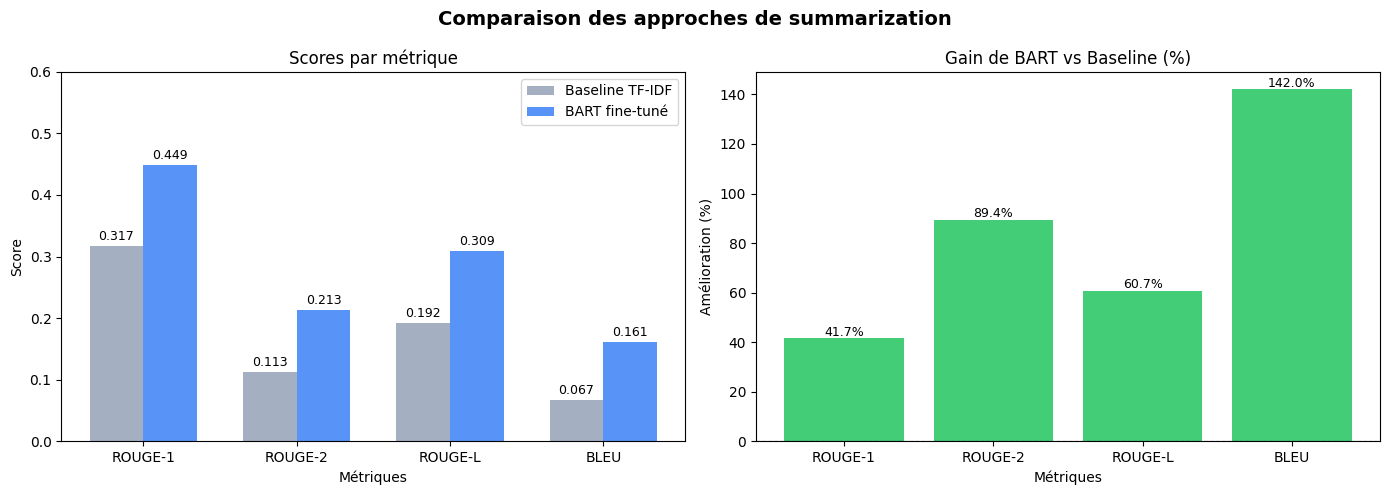

✅ Graphique sauvegardé


In [9]:
# ╔══════════════════════════════════════════════╗
# ║          COMPARAISON DES APPROCHES           ║
# ╚══════════════════════════════════════════════╝

# Tableau comparatif
comparison_df = pd.DataFrame({
    "Approche":      ["Baseline TF-IDF (extractif)", "BART-large-CNN (fine-tuné)"],
    "Type":          ["Extractive", "Abstractive"],
    "Architecture":  ["TF-IDF + scoring", "Transformer Encoder-Decoder"],
    "ROUGE-1":       [baseline_scores["rouge1"], finetuned_scores["rouge1"]],
    "ROUGE-2":       [baseline_scores["rouge2"], finetuned_scores["rouge2"]],
    "ROUGE-L":       [baseline_scores["rougeL"], finetuned_scores["rougeL"]],
    "BLEU":          [baseline_scores["bleu"],   finetuned_scores["bleu"]],
})

print("\n📊 TABLEAU COMPARATIF COMPLET")
print("="*80)
print(comparison_df.to_string(index=False))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Comparaison des approches de summarization", fontsize=14, fontweight='bold')

metrics   = ["ROUGE-1", "ROUGE-2", "ROUGE-L", "BLEU"]
baseline_vals  = [baseline_scores["rouge1"], baseline_scores["rouge2"],
                  baseline_scores["rougeL"], baseline_scores["bleu"]]
finetuned_vals = [finetuned_scores["rouge1"], finetuned_scores["rouge2"],
                  finetuned_scores["rougeL"], finetuned_scores["bleu"]]

x = np.arange(len(metrics))
width = 0.35

bars1 = axes[0].bar(x - width/2, baseline_vals,  width, label="Baseline TF-IDF", color="#94a3b8", alpha=0.85)
bars2 = axes[0].bar(x + width/2, finetuned_vals, width, label="BART fine-tuné",  color="#3b82f6", alpha=0.85)

axes[0].set_xlabel("Métriques")
axes[0].set_ylabel("Score")
axes[0].set_title("Scores par métrique")
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].legend()
axes[0].set_ylim(0, 0.6)
for bar in bars1: axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2: axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

# Amélioration relative
improvements = [(f-b)/b*100 if b > 0 else 0 for f, b in zip(finetuned_vals, baseline_vals)]
colors = ["#22c55e" if v >= 0 else "#ef4444" for v in improvements]
axes[1].bar(metrics, improvements, color=colors, alpha=0.85)
axes[1].axhline(y=0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_xlabel("Métriques")
axes[1].set_ylabel("Amélioration (%)")
axes[1].set_title("Gain de BART vs Baseline (%)")
for i, v in enumerate(improvements):
    axes[1].text(i, v + (1 if v >= 0 else -3), f'{v:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig("/kaggle/working/comparison_plot.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique sauvegardé")


## 10. Pipeline PDF → Résumés par section

In [10]:
# ╔══════════════════════════════════════════════╗
# ║     EXTRACTION PDF — DÉTECTION DES TITRES    ║
# ╚══════════════════════════════════════════════╝

def extract_sections_from_pdf(pdf_path):
    """
    Extrait le texte d'un PDF et détecte les sections par titre.
    Retourne : dict {titre: texte_de_la_section}
    """
    sections = {}
    current_title = "Introduction"
    current_text  = []
    
    # Patterns pour détecter les titres
    title_patterns = [
        r'^\d+\.\s+[A-Z][\w\s]{3,60}$',           # "1. Introduction"
        r'^\d+\.\d+\.?\s+[A-Z][\w\s]{3,50}$',   # "1.1 Subsection"
        r'^[A-Z][A-Z\s]{4,50}$',                       # "INTRODUCTION"
        r'^(?:Chapter|Section|Part)\s+\d+',            # "Chapter 1"
        r'^[IVX]+\.\s+[A-Z][\w\s]{3,50}$',          # "I. Introduction"
    ]
    
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            text = page.extract_text()
            if not text:
                continue
            
            for line in text.split('\n'):
                line_stripped = line.strip()
                if not line_stripped:
                    continue
                
                # Vérifier si c'est un titre
                is_title = any(re.match(p, line_stripped) for p in title_patterns)
                
                # Heuristique supplémentaire : ligne courte en début de page/section
                if not is_title and len(line_stripped) < 80 and len(line_stripped) > 5:
                    words = line_stripped.split()
                    if len(words) <= 8 and line_stripped[0].isupper():
                        # Vérifie que ce n'est pas juste une phrase normale
                        if not line_stripped.endswith('.') and not line_stripped.endswith(','):
                            is_title = True
                
                if is_title:
                    # Sauvegarder la section précédente
                    if current_text:
                        existing = sections.get(current_title, "")
                        sections[current_title] = existing + " " + " ".join(current_text)
                    current_title = line_stripped
                    current_text  = []
                else:
                    current_text.append(line_stripped)
        
        # Dernière section
        if current_text:
            existing = sections.get(current_title, "")
            sections[current_title] = existing + " " + " ".join(current_text)
    
    # Nettoyage : garder seulement les sections avec assez de texte
    sections = {
        title: re.sub(r'\s+', ' ', text).strip()
        for title, text in sections.items()
        if len(text.split()) >= 30
    }
    
    return sections

def summarize_section(text, title=""):
    """Génère un résumé pour une section donnée"""
    # Si le texte est trop court, le retourner tel quel
    if len(text.split()) < 50:
        return text
    
    # Tronquer si nécessaire
    words = text.split()
    if len(words) > 700:
        text = ' '.join(words[:700])
    
    inputs = tokenizer(
        text,
        max_length=CONFIG["max_input_length"],
        truncation=True,
        return_tensors="pt"
    ).to(DEVICE)
    
    with torch.no_grad():
        summary_ids = model.generate(
            inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            num_beams=CONFIG["num_beams"],
            min_length=CONFIG["min_summary_length"],
            max_length=CONFIG["max_summary_length"],
            length_penalty=CONFIG["length_penalty"],
            no_repeat_ngram_size=CONFIG["no_repeat_ngram_size"],
            early_stopping=True,
        )
    
    return tokenizer.decode(summary_ids[0], skip_special_tokens=True)

print("✅ Fonctions d'extraction PDF définies")


✅ Fonctions d'extraction PDF définies


## 11. Génération des résumés et création du PDF final

In [11]:
def process_course_pdf(pdf_path):
    print(f"\n📖 Traitement : {Path(pdf_path).name}")
    sections = extract_sections_from_pdf(pdf_path)
    if not sections:
        print("  ⚠️  Aucune section détectée dans ce PDF")
        return {}
    summaries = {}
    for title, text in sections.items():
        summary = summarize_section(text, title)
        summaries[title] = {
            "original_words": len(text.split()),
            "summary": summary,
            "summary_words": len(summary.split()),
            "compression_ratio": round(len(summary.split()) / max(len(text.split()), 1) * 100, 1)
        }
    return summaries


def generate_summary_pdf(all_summaries, output_path, course_name="Cours Académique"):
    pdf = FPDF()
    pdf.set_auto_page_break(auto=True, margin=15)

    for pdf_name, summaries in all_summaries.items():
        for i, (title, data) in enumerate(summaries.items(), 1):
            pdf.add_page()
            pdf.set_font("Helvetica", "B", 14)
            pdf.multi_cell(0, 10, title.encode("latin-1", errors="replace").decode("latin-1"))
            pdf.ln(3)
            pdf.set_font("Helvetica", "", 11)
            pdf.multi_cell(0, 7, data["summary"].encode("latin-1", errors="replace").decode("latin-1"))
            pdf.ln(5)

    pdf.output(output_path)
    print(f"\n✅ PDF généré : {output_path}")
    return output_path


# Traitement
try:
    pdf_files = list(Path(CONFIG["pdf_input_dir"]).rglob("*.pdf"))
except (FileNotFoundError, OSError):
    pdf_files = []

if not pdf_files:
    print("⚠️  Aucun PDF trouvé → démonstration synthétique...")
    demo_texts = {
        "1. Introduction to NLP": "Natural language processing is a subfield of linguistics and AI concerned with interactions between computers and human language. The goal is a computer capable of understanding documents including contextual nuances.",
        "2. Transformer Architecture": "The Transformer is a deep learning model using self-attention. Introduced in 2017 in Attention Is All You Need. BERT, GPT, T5 and BART are all based on this architecture.",
        "3. Text Summarization": "Summarization condenses text while preserving key information. Extractive methods select sentences, abstractive methods generate new text. BART achieves state-of-the-art results on CNN/DailyMail.",
    }
    demo_sections = {}
    for title, text in demo_texts.items():
        summary = generate_summary(text)
        demo_sections[title] = {
            "original_words": len(text.split()),
            "summary": summary,
            "summary_words": len(summary.split()),
            "compression_ratio": round(len(summary.split()) / max(len(text.split()), 1) * 100, 1)
        }
    all_summaries = {"Démonstration NLP": demo_sections}
    course_name = "Cours NLP"
else:
    print(f"✅ {len(pdf_files)} PDF(s) trouvé(s)")
    all_summaries = {}
    for pdf_path in pdf_files:
        summaries = process_course_pdf(str(pdf_path))
        if summaries:
            all_summaries[pdf_path.stem] = summaries
    course_name = pdf_files[0].stem

output_pdf = generate_summary_pdf(all_summaries, CONFIG["pdf_output_path"], course_name)
print("\n🎉 PIPELINE COMPLET TERMINÉ !")
print(f"   📄 PDF : {CONFIG['pdf_output_path']}")

✅ 1 PDF(s) trouvé(s)

📖 Traitement : Chapter2.pdf

✅ PDF généré : /kaggle/working/course_summaries.pdf

🎉 PIPELINE COMPLET TERMINÉ !
   📄 PDF : /kaggle/working/course_summaries.pdf


## 12. Résultats finaux et analyse

In [12]:
# ╔══════════════════════════════════════════════╗
# ║          RÉSUMÉ FINAL DU PROJET              ║
# ╚══════════════════════════════════════════════╝

print("\n" + "="*65)
print("  RÉSULTATS FINAUX — NLP MINI-PROJECT")
print("="*65)

print("\n📊 TABLEAU COMPARATIF DES APPROCHES")
print("-"*65)
print(f"{'Approche':<30} {'ROUGE-1':>8} {'ROUGE-2':>8} {'ROUGE-L':>8} {'BLEU':>8}")
print("-"*65)
print(f"{'Baseline TF-IDF (extractif)':<30} {baseline_scores['rouge1']:>8.4f} {baseline_scores['rouge2']:>8.4f} {baseline_scores['rougeL']:>8.4f} {baseline_scores['bleu']:>8.4f}")
print(f"{'BART fine-tuné (abstractif)':<30} {finetuned_scores['rouge1']:>8.4f} {finetuned_scores['rouge2']:>8.4f} {finetuned_scores['rougeL']:>8.4f} {finetuned_scores['bleu']:>8.4f}")
print("-"*65)

gain_r1 = (finetuned_scores['rouge1'] - baseline_scores['rouge1']) / baseline_scores['rouge1'] * 100
gain_r2 = (finetuned_scores['rouge2'] - baseline_scores['rouge2']) / baseline_scores['rouge2'] * 100
print(f"\n  Gain ROUGE-1 : {gain_r1:+.1f}%")
print(f"  Gain ROUGE-2 : {gain_r2:+.1f}%")

print("\n✅ CHECKLIST PROJET")
print("-"*65)
checklist = [
    ("Modèle NLP implémenté", "BART-large-CNN (Transformer encoder-decoder)"),
    ("Preprocessing / Tokenisation", "AutoTokenizer BART, troncature 1024 tokens"),
    ("Entraînement du modèle", f"Fine-tuning {CONFIG['epochs']} epochs, lr={CONFIG['learning_rate']}"),
    ("Métriques d'évaluation", "ROUGE-1, ROUGE-2, ROUGE-L, BLEU"),
    ("Architecture moderne", "Transformer (BART = BERT encoder + GPT decoder)"),
    ("Comparaison d'approches", "TF-IDF extractif vs BART abstractif"),
    ("Application réelle", "PDF de cours → résumés par section → PDF final"),
]
for item, detail in checklist:
    print(f"  ✅ {item:<35} → {detail}")

print("\n📁 FICHIERS GÉNÉRÉS")
print("-"*65)
import os
outputs = [
    CONFIG["pdf_output_path"],
    CONFIG["output_dir"],
    "/kaggle/working/comparison_plot.png"
]
for f in outputs:
    exists = "✅" if os.path.exists(f) else "⚠️ "
    print(f"  {exists} {f}")



  RÉSULTATS FINAUX — NLP MINI-PROJECT

📊 TABLEAU COMPARATIF DES APPROCHES
-----------------------------------------------------------------
Approche                        ROUGE-1  ROUGE-2  ROUGE-L     BLEU
-----------------------------------------------------------------
Baseline TF-IDF (extractif)      0.3167   0.1125   0.1924   0.0666
BART fine-tuné (abstractif)      0.4487   0.2131   0.3092   0.1613
-----------------------------------------------------------------

  Gain ROUGE-1 : +41.7%
  Gain ROUGE-2 : +89.4%

✅ CHECKLIST PROJET
-----------------------------------------------------------------
  ✅ Modèle NLP implémenté               → BART-large-CNN (Transformer encoder-decoder)
  ✅ Preprocessing / Tokenisation        → AutoTokenizer BART, troncature 1024 tokens
  ✅ Entraînement du modèle              → Fine-tuning 2 epochs, lr=2e-05
  ✅ Métriques d'évaluation              → ROUGE-1, ROUGE-2, ROUGE-L, BLEU
  ✅ Architecture moderne                → Transformer (BART = BERT encod